In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#121212",
    "figure.facecolor": "#121212",
    "grid.color": "#2a2a2a",
    "text.color": "#e0e0e0",
    "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0"
})

print("[+] Environment initialized.")

[+] Environment initialized.


In [2]:
df = pd.read_csv('../data/processed/analytics_base.csv')

usd_90th = df['Size USD'].quantile(0.90)
df['trader_tier'] = np.where(df['Size USD'] >= usd_90th, 'Whale', 'Retail')
df['is_winning_trade'] = (df['net_pnl'] > 0).astype(int)

regime_stats = df.groupby('sentiment_regime').agg(
    win_rate=('is_winning_trade', 'mean'),
    avg_net_pnl=('net_pnl', 'mean')
).reset_index()
regime_stats['win_rate'] = regime_stats['win_rate'] * 100

print("[+] Data loaded and features engineered.")
df.head(3)

[+] Data loaded and features engineered.


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Direction,net_pnl,date_join,Timestamp_UTC,sentiment_score,sentiment_regime,trader_tier,is_winning_trade
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,Buy,-0.345404,2024-12-02,2024-12-02 17:20:00,80,Extreme Greed,Retail,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,Buy,-0.005600,2024-12-02,2024-12-02 17:20:00,80,Extreme Greed,Retail,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,Buy,-0.050431,2024-12-02,2024-12-02 17:20:00,80,Extreme Greed,Retail,0


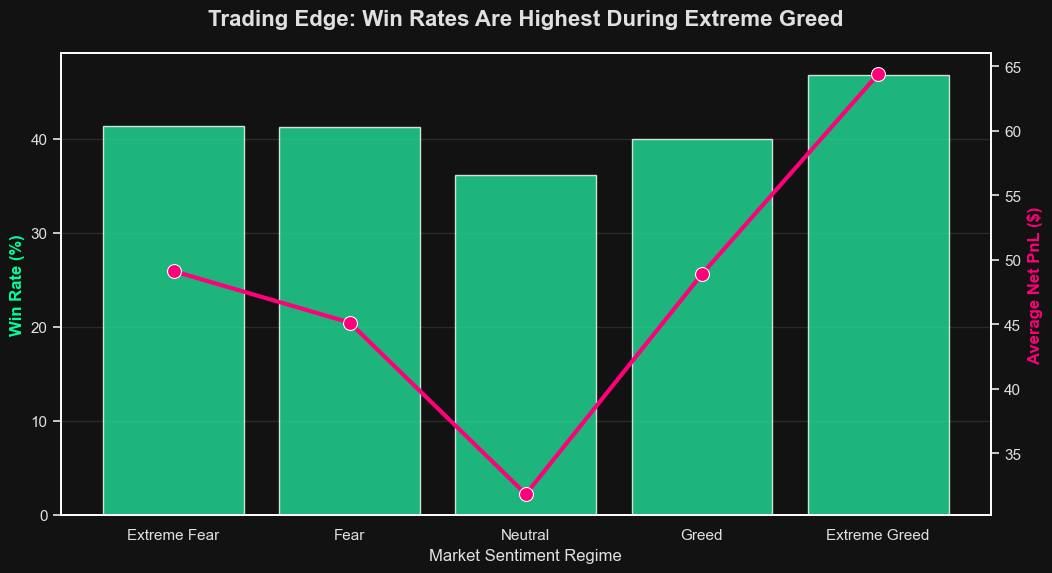

In [3]:
# Chart 1: Win Rate & Profitability by Market Regime
fig, ax1 = plt.subplots(figsize=(12, 6))

# Order the regimes logically and sort the dataframe first
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
regime_stats['sentiment_regime'] = pd.Categorical(regime_stats['sentiment_regime'], categories=order, ordered=True)
regime_stats = regime_stats.sort_values('sentiment_regime')

# Bar chart for Win Rate (order is handled by the sorted dataframe)
sns.barplot(data=regime_stats, x='sentiment_regime', y='win_rate', 
            color='#00ff9d', alpha=0.8, ax=ax1)
ax1.set_ylabel('Win Rate (%)', color='#00ff9d', fontsize=12, fontweight='bold')
ax1.set_xlabel('Market Sentiment Regime', fontsize=12)
ax1.set_title('Trading Edge: Win Rates Are Highest During Extreme Greed', fontsize=16, pad=20, fontweight='bold')

# Line chart for Average PnL on secondary axis (removed the 'order' parameter)
ax2 = ax1.twinx()
sns.lineplot(data=regime_stats, x='sentiment_regime', y='avg_net_pnl', 
             color='#ff007a', marker='o', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Average Net PnL ($)', color='#ff007a', fontsize=12, fontweight='bold')
ax2.grid(False)

plt.show()

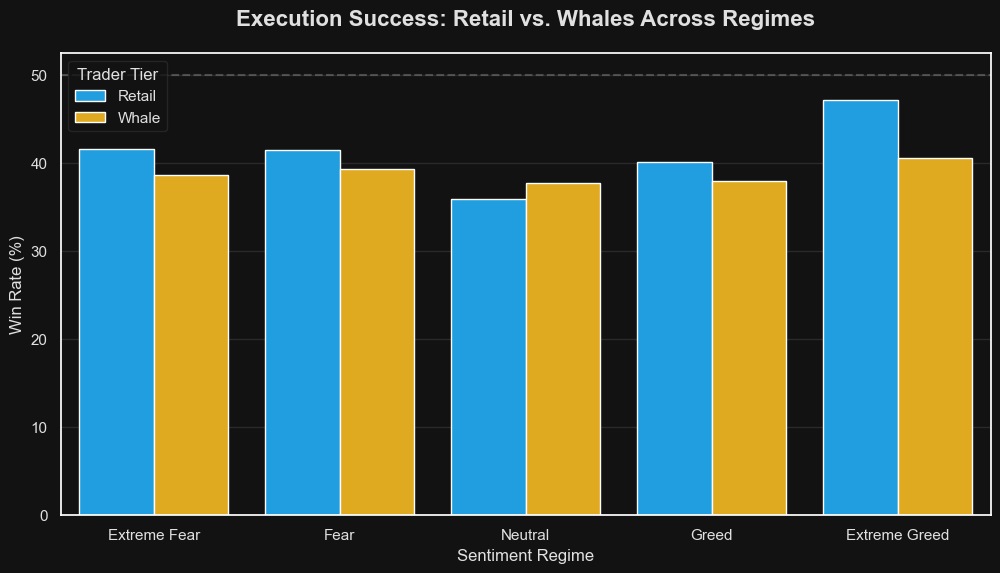

In [4]:
tier_stats = df.groupby(['sentiment_regime', 'trader_tier'])['is_winning_trade'].mean().reset_index()
tier_stats = tier_stats.rename(columns={'is_winning_trade': 'win_rate'})
tier_stats['win_rate'] = tier_stats['win_rate'] * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=tier_stats, x='sentiment_regime', y='win_rate', hue='trader_tier', 
            order=order, palette=['#00a8ff', '#ffb700'])

plt.title('Execution Success: Retail vs. Whales Across Regimes', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Win Rate (%)', fontsize=12)
plt.xlabel('Sentiment Regime', fontsize=12)
plt.legend(title='Trader Tier', facecolor='#121212', edgecolor='#2a2a2a')
plt.axhline(50, color='gray', linestyle='--', alpha=0.5) # Breakeven reference line

plt.show()

In [5]:
# 1. Calculate Average Win and Average Loss per regime
avg_win = df[df['net_pnl'] > 0].groupby('sentiment_regime')['net_pnl'].mean()
avg_loss = df[df['net_pnl'] < 0].groupby('sentiment_regime')['net_pnl'].mean().abs()

# 2. Get Win Rates and Loss Rates
win_rate = df.groupby('sentiment_regime')['is_winning_trade'].mean()
loss_rate = 1 - win_rate

# 3. Calculate Mathematical Expectancy
expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)

print("Expected Value (EV) per Trade by Regime:")
print("-" * 45)
for regime, ev in expectancy.sort_values(ascending=False).items():
    print(f"{regime.ljust(15)}: ${ev:.2f} per trade")

Expected Value (EV) per Trade by Regime:
---------------------------------------------
Extreme Greed  : $64.21 per trade
Greed          : $48.70 per trade
Fear           : $44.70 per trade
Extreme Fear   : $44.19 per trade
Neutral        : $31.71 per trade
